# Práctica 04: Análisis de Datos Exploratorio con Python y Jupyter Notebook en un Dataset de Productos de Amazon Store #

**Programa de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Análitica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramiréz Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** José de Jesús Hernández Casiano \
**Matricula:** 230535 \
**Grado y Grupo:** 9A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30PX; border-radius: 15px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: white; font-size: 2.2em; margin: 0;">Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML) </h1>
    <p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Predicción de Precisos - Análisis de Catrgorías - Ingeniería de Funcionalidades - Comparación de Modeles </p>
</div>

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones y Carga de Datos](#s1) | Librerias, carga de CSV, Primeros Comandos de Estructura |
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnasy calcular el % de datos faltantes |
| 3 | [Limpieza de Datos](#s3) | Análisis de precios, valores faltantes, duplicados |
| 4 | [Feature Engineering](#s4) | Características del texto, indicadores de categoría, niveles de precios |
| 5 | [Análisis Univariado](#s5) | Distribuciones, valores atípicos, pruebas de normalidad |
| 6 | [Análisis de Categorías](#s6) | Categorías principales, precio por categoría |
| 7 | [Análisis de Disponibilidad](#s2) | Patrones de estado de existencias |

## 1.- Instalaciones & Carga de Datos  <a id='s1'></a>

<div style="background: #F0F8FF; padding: 12px; border-left: 4px solid #FF9900; border-radius: 5px00; color: #0066CC">
    <b>Dataset: </b> Amazon India Listas de Productos - 1,436 productos entre Libros, Kindle, Deportes & mas <br> 
    <b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre y disponibilidad <br>
    <b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [1]:
# ====================================================
# SECTION 1 - Setup & Data Loading
# ====================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

print(f'✅ Pandas : {pd.__version__}')
print(f'✅ NumPy : {np.__version__}')
print('✅ Todas las librerias cargaron con éxito!')

✅ Pandas : 2.3.3
✅ NumPy : 2.3.5
✅ Todas las librerias cargaron con éxito!


In [2]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f' Shape : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

 Shape : (1436, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de Datos del DataFrame.

In [3]:
# Column Dictionary
col_info = {
    'rl'              : 'URL del Producto en Amazon.in',
    'asin'             : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'             : 'Nombre o Título del Proyecto',
    'overview'         : 'Breve Reseña del Producto (mayoría vacío[])',
    'price'            : 'Precio como string (e.g. "1,600.00")',
    'currency'         : 'Código de Divisa (todas en INR)',
    'availability'     : 'Texto del Status del Stock (Inventario)',
    'brand'            : 'Nombre de la Marca/Autor',
    'about_item'       : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'       : 'URLs de Imágenes del Producto',
    'description'      : 'Descrpción Detallada y Completa (mayoría faltante)',
    'specifications'   : 'Especificaciones Técnicas',
    'primary_category' : 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'       : 'Subcategoría de nivel 1',
    'category_2'       : 'Subcategoría de nivel 2',
    'category_3'       : 'Subcategoría de nivel 3',
    'breadcrumbs'      : 'Ruta de Categorías',
}
print ('Diccionario por Columnas')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print (
        f'{col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
    )

Diccionario por Columnas
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título del Proyecto                  | Missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío[])   | Missing: 0%
price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 24%
availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
brand                | Nombre de la Marca/Autor                      | Missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
img_source           | URLs de Imágenes del Producto                 | Missing: 0%
description          | Descrpción Detallada y Completa (mayoría falt | Missing: 92%
specifications       | Especificaciones Técnicas         

## 3.- Limpieza de Datos

<div style="background:#fff8e1; padding:12px; border-left:4px solid #ff9900; border-radius:5px; color:#0066cc">
    <b>Pasos clave para la limpieza:</b><br>
    - Pareseas el precio string como "1,600.00" -> float 1600.0 <br>
    - Manejar los datos faltantes (price: 24%, availability: 33%,, description: 92%) <br>
    - Estandarizarel texto de disponibilidad en categorías limpias <br>
    - Eliminar duplicados
</div>

In [4]:
# ============================================================
# SECTION 3 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,092 / 1,436 products
✅ Duplicate ASINs: 0
✅ Availability categories: {'In Stock': 607, 'Unknown': 477, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


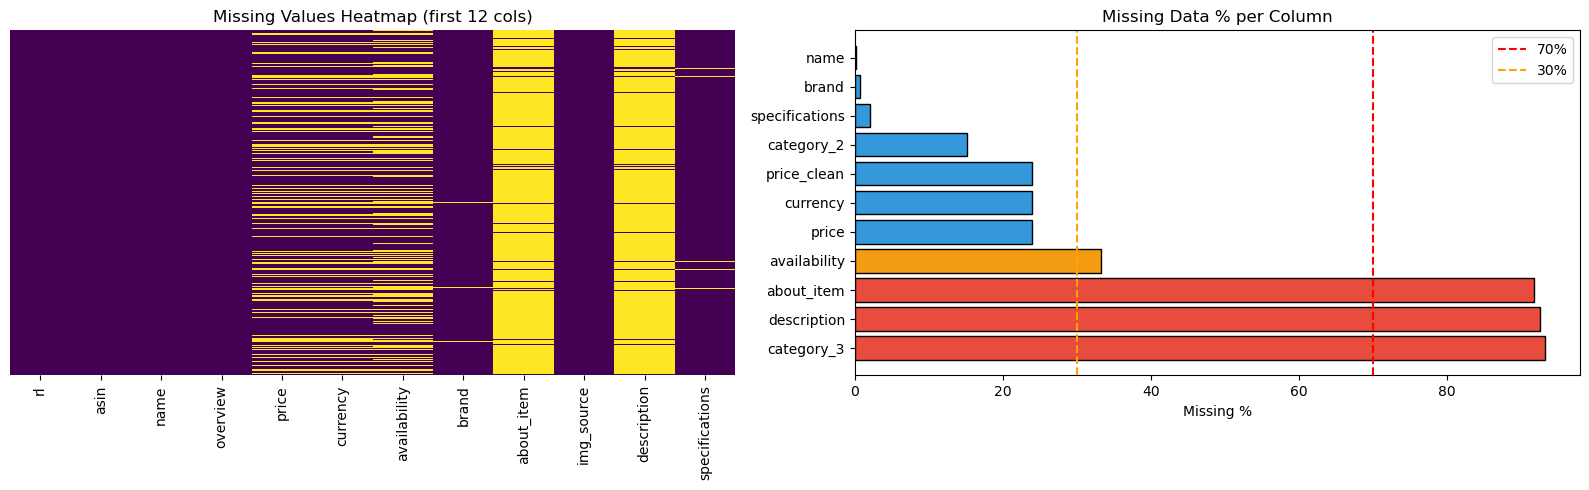

                Missing Count  Missing Pct
category_3               1340         93.3
description              1328         92.5
about_item               1317         91.7
availability              477         33.2
price                     344         24.0
currency                  344         24.0
price_clean               344         24.0
category_2                218         15.2
specifications             29          2.0
brand                      10          0.7
name                        1          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())

## 4.- Feature Engineering

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #ff9900; border-radius:5px 0 0 5px; color:#0066cc;">
    <b>Ejemplo Cotidiano:</b><br>
    Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino tambien considera la ubicación, la antiguedad y el estado. Nosotros hacemos lo mismo: extraemos la información más valiosa del texto sin procesar categorías. 
    <div/>

In [ ]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

## 5.- Análisis Univariado

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #ff9900; border-radius:5px 0 0 5px; color:#0066cc;">
    <b>Pregunta Clave</b><br>
    ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
    <div/>

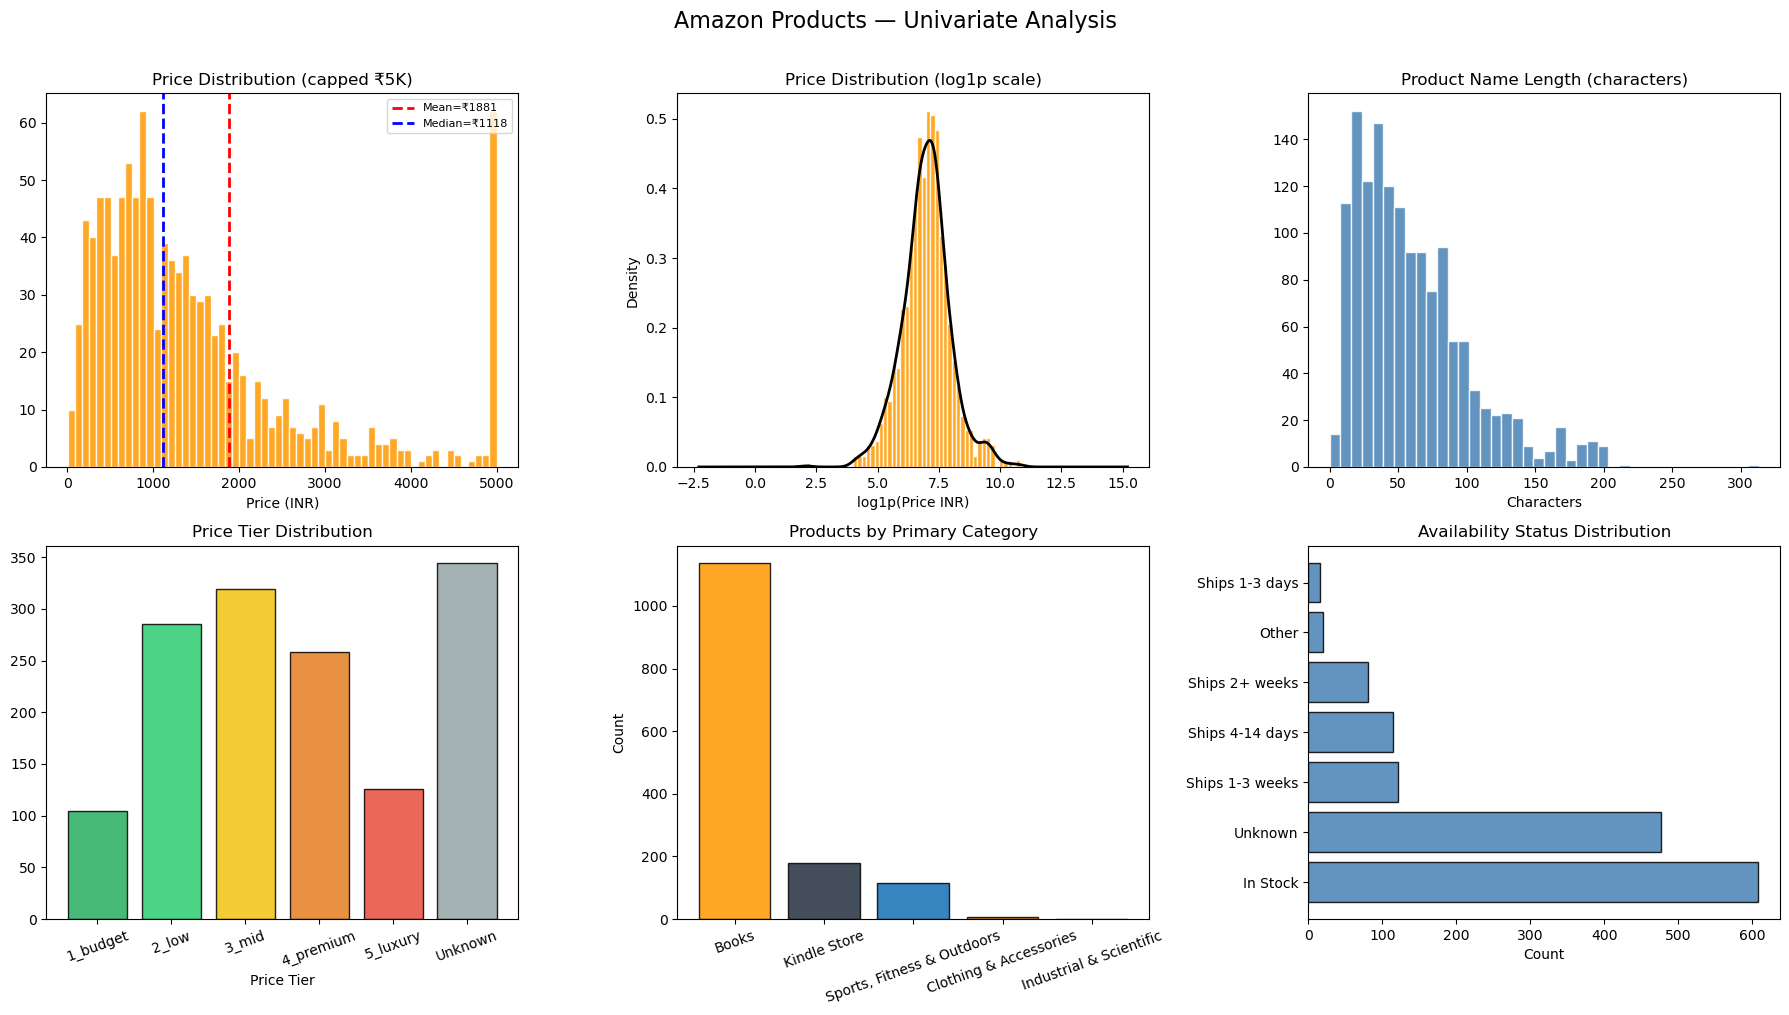

NameError: name 'shapiro' is not defined

In [8]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

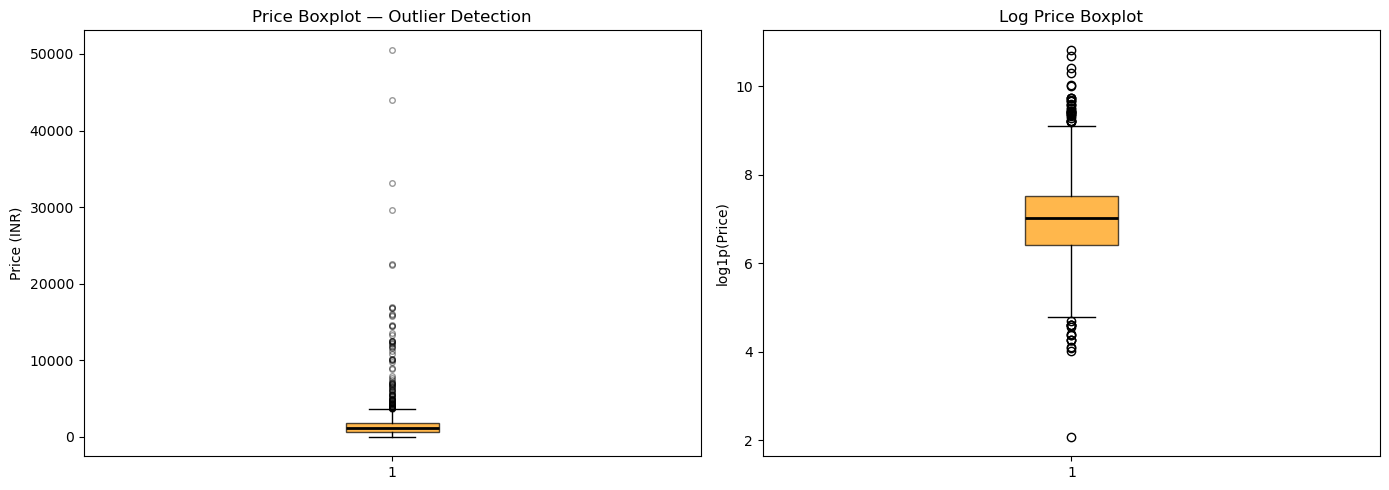

IQR method outliers: 93 (8.6%)
Price range (non-outlier): ₹-1245 – ₹3707

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [9]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.- Análisis de Categorías

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #ff9900; border-radius:5px 0 0 5px; color:#0066cc;">
    <b>Pregunta Clave</b><br>
    ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?
    <div/>

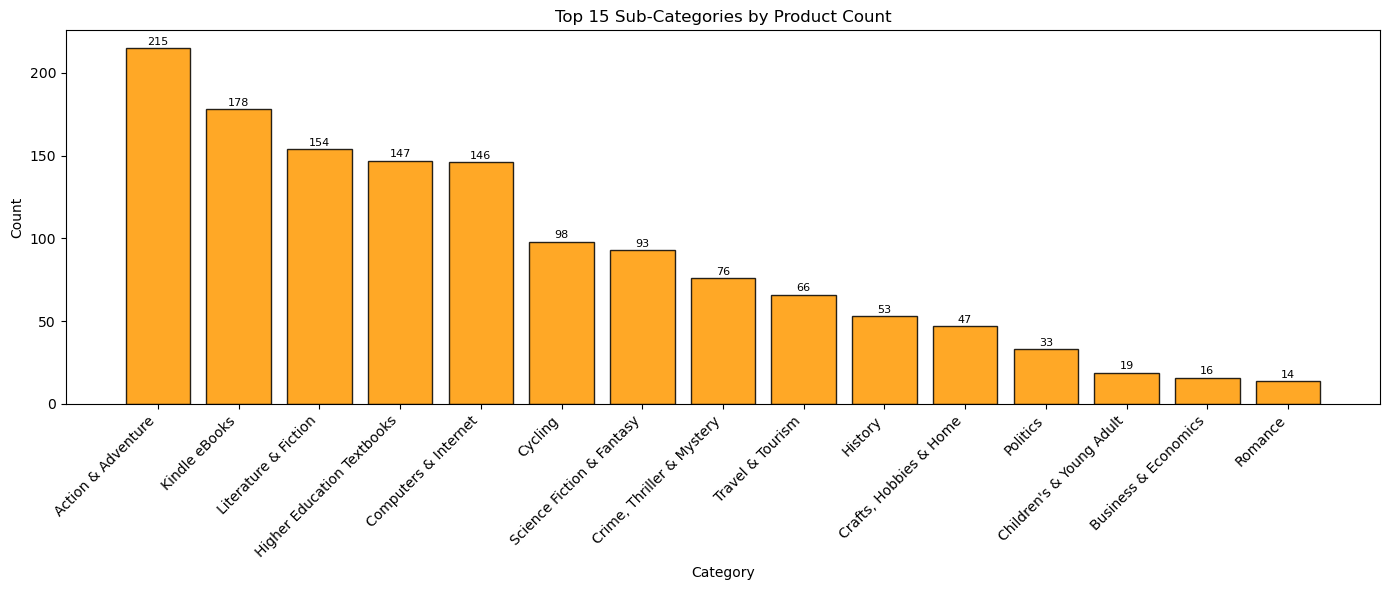

In [10]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

C:\Users\PC-19\AppData\Local\Temp\ipykernel_10944\1881029386.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


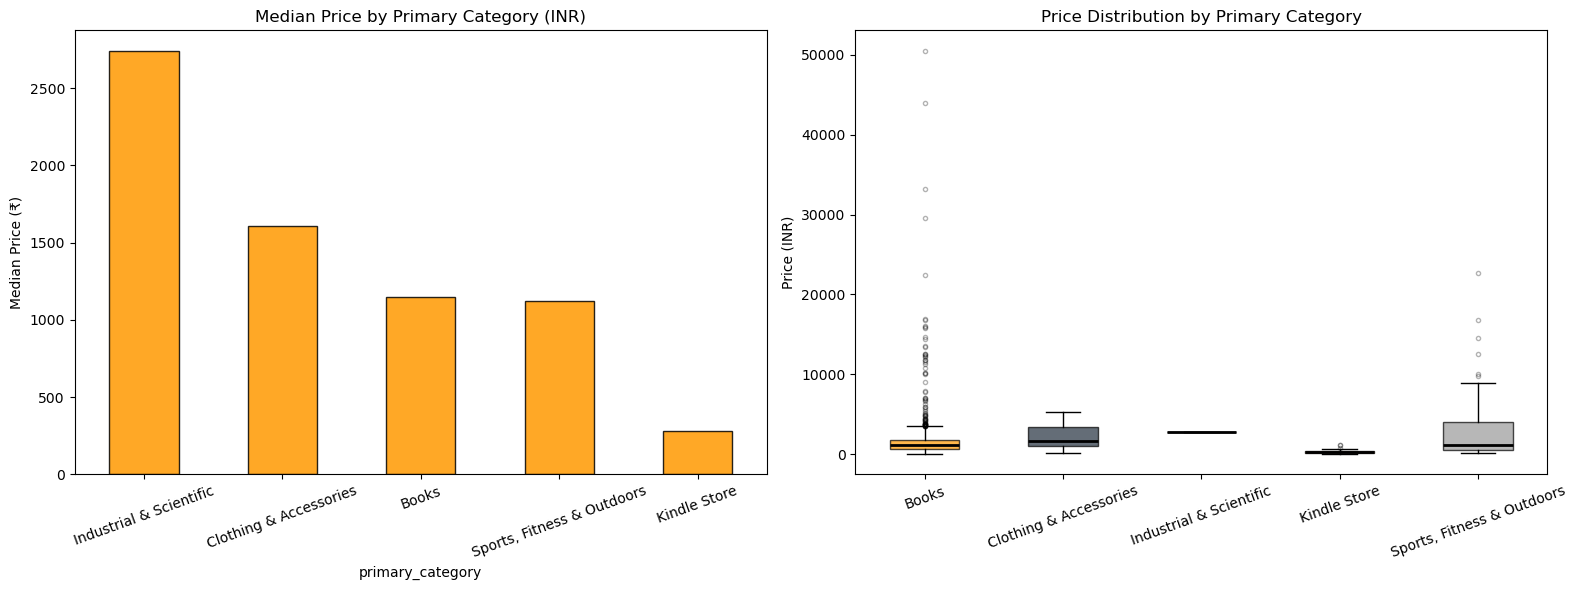

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [11]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())

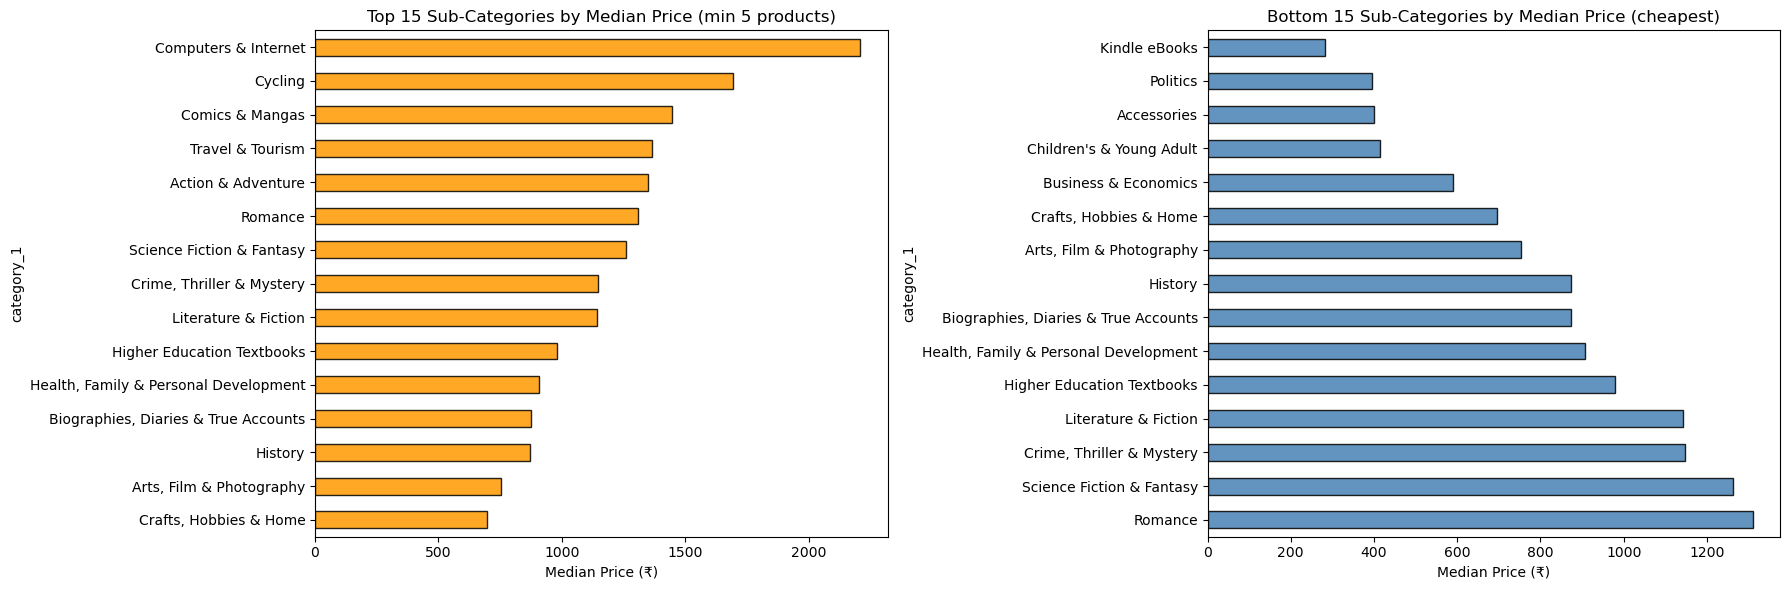

In [13]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.- Análisis de Disponibilidad

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #ff9900; border-radius:5px 0 0 5px; color:#0066cc;">
    <b>Pregunta Clave</b><br>
    ¿Influye la disponibilidad en el precio? ¿Es más probable que los productos premium se agoten?
    <div/>

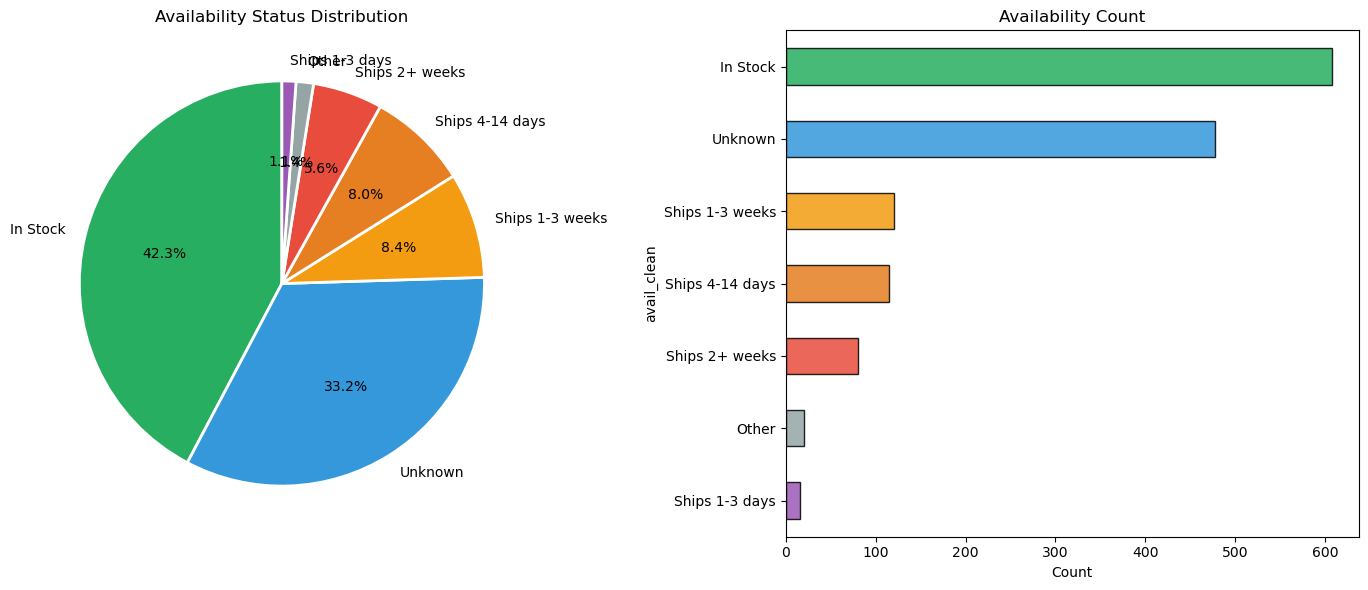

In [14]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

C:\Users\PC-19\AppData\Local\Temp\ipykernel_10944\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


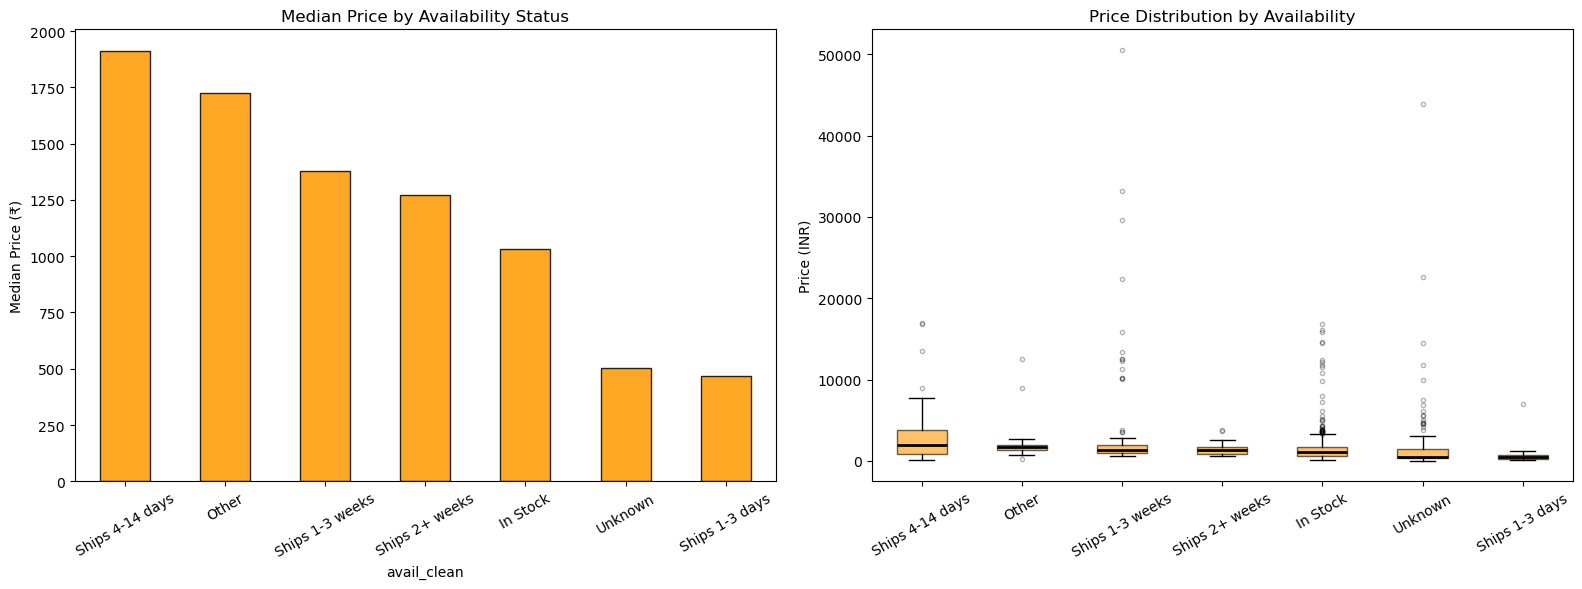

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.0  1490.5    599
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [15]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())